## Baseline Leaderboard

`baseline_5.ipynb` Step 6이 저장한 `BASELINE/baseline_5_results.csv`를 읽어, 모델별·그룹별 NMAE/FICR/공식 총점을 비교합니다.

먼저 baseline 실험 노트북의 Step 6을 실행한 뒤 이 노트북을 실행하세요. 같은 형식의 `baseline_*_results.csv` 파일이 추가되면 자동으로 함께 비교합니다.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("/Users/ksydata/WINDFORCE")
RESULT_DIR = ROOT / "BASELINE"
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.4f}".format


### 1. 실험 결과 불러오기


In [2]:
result_paths = sorted(RESULT_DIR.glob("baseline_*_results.csv"))
if not result_paths:
    raise FileNotFoundError(
        "결과 파일이 없습니다. baseline_5.ipynb의 Step 6을 실행해 "
        "BASELINE/baseline_5_results.csv를 먼저 생성하세요."
    )

frames = []
for path in result_paths:
    frame = pd.read_csv(path, encoding="utf-8-sig")
    required = {"group", "model_name", "nmae", "ficr"}
    missing = required - set(frame.columns)
    if missing:
        print(f"건너뜀: {path.name} (필수 열 누락: {sorted(missing)})")
        continue
    frame["baseline"] = path.stem.replace("_results", "")
    frames.append(frame)
if not frames:
    raise ValueError("읽을 수 있는 baseline 결과 파일이 없습니다.")

results = pd.concat(frames, ignore_index=True)
results["model_id"] = results["baseline"] + " / " + results["model_name"]
display(results.sort_values(["baseline", "model_name", "group"]).reset_index(drop=True))


,group,model_name,nmae,ficr,score,baseline,model_id
0,1,LSTM,0.2103,0.1584,0.4740,baseline_5,baseline_5 / LSTM
1,2,LSTM,0.2259,0.2305,0.5023,baseline_5,baseline_5 / LSTM
2,3,LSTM,0.1590,0.1642,0.5026,baseline_5,baseline_5 / LSTM
3,1,Persistence_oracle_lag1,0.0504,0.6239,0.7867,baseline_5,baseline_5 / Persistence_oracle_lag1
4,2,Persistence_oracle_lag1,0.0475,0.6674,0.8099,baseline_5,baseline_5 / Persistence_oracle_lag1
5,3,Persistence_oracle_lag1,0.0425,0.6256,0.7915,baseline_5,baseline_5 / Persistence_oracle_lag1
6,1,SVR,0.2315,0.0847,0.4266,baseline_5,baseline_5 / SVR
7,2,SVR,0.2491,0.0734,0.4122,baseline_5,baseline_5 / SVR
8,3,SVR,0.2033,0.0902,0.4435,baseline_5,baseline_5 / SVR


### 2. 공식 총점 리더보드

그룹별 NMAE와 FICR를 먼저 평균한 뒤 `0.5 × (1 - mean NMAE) + 0.5 × mean FICR`으로 계산합니다.


In [3]:
leaderboard = (results.groupby(["baseline", "model_name"], as_index=False)
               .agg(mean_nmae=("nmae", "mean"), mean_ficr=("ficr", "mean"), groups=("group", "nunique")))
leaderboard["official_score"] = 0.5 * (1 - leaderboard["mean_nmae"]) + 0.5 * leaderboard["mean_ficr"]
leaderboard = leaderboard.sort_values("official_score", ascending=False).reset_index(drop=True)
leaderboard.insert(0, "rank", leaderboard.index + 1)
display(leaderboard)


,rank,baseline,model_name,mean_nmae,mean_ficr,groups,official_score
0,1,baseline_5,Persistence_oracle_lag1,0.0468,0.6389,3,0.7961
1,2,baseline_5,LSTM,0.1984,0.1844,3,0.4930
2,3,baseline_5,SVR,0.2279,0.0828,3,0.4274


### 3. 그룹별 비교


In [4]:
group_score = results.pivot_table(index="model_id", columns="group", values="score", aggfunc="first")
group_score = group_score.reindex(leaderboard["baseline"] + " / " + leaderboard["model_name"])
group_score.columns = [f"KPX 그룹 {g}" for g in group_score.columns]
display(group_score.style.format("{:.4f}").background_gradient(axis=None, cmap="YlGnBu"))


,KPX 그룹 1,KPX 그룹 2,KPX 그룹 3
baseline_5 / Persistence_oracle_lag1,0.7867,0.8099,0.7915
baseline_5 / LSTM,0.4740,0.5023,0.5026
baseline_5 / SVR,0.4266,0.4122,0.4435


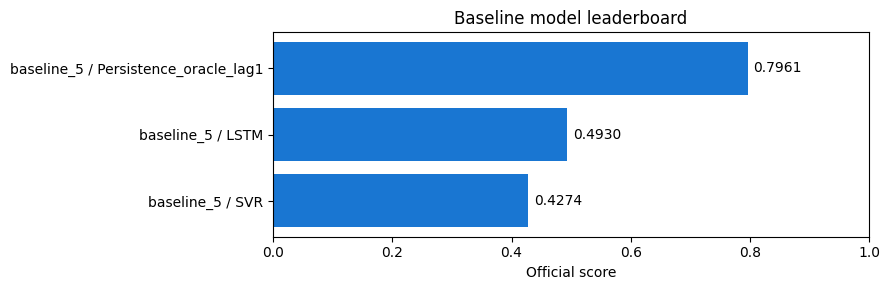

In [5]:
plot_df = leaderboard.sort_values("official_score")
fig, ax = plt.subplots(figsize=(9, max(3, 0.55 * len(plot_df))))
ax.barh(plot_df["baseline"] + " / " + plot_df["model_name"], plot_df["official_score"], color="#1976D2")
ax.set_xlabel("Official score")
ax.set_title("Baseline model leaderboard")
ax.set_xlim(0, 1)
for i, value in enumerate(plot_df["official_score"]):
    ax.text(value + 0.01, i, f"{value:.4f}", va="center")
plt.tight_layout()
plt.show()
